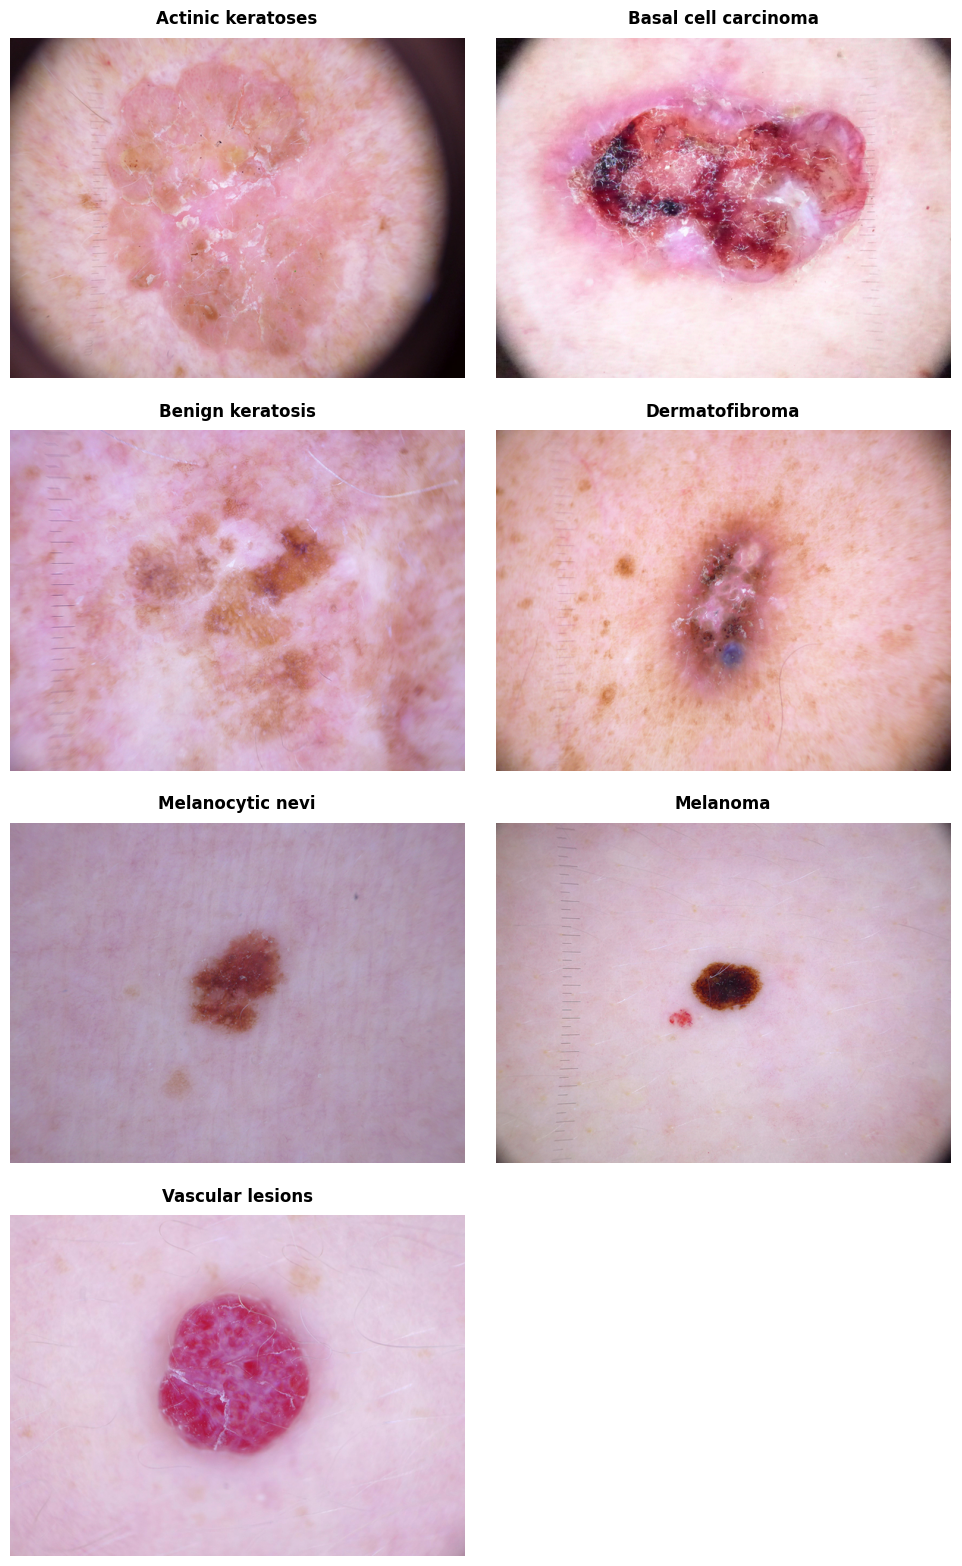

Saved: Figure_3_2_Sample_Dermoscopic_Images.png


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ==========================
# PATHS
# ==========================
CSV_PATH = "../data/HAM10000_metadata.csv"

IMG_DIRS = [
    "../data/HAM10000_images_part_1",
    "../data/HAM10000_images_part_2"
]

# ==========================
# LOAD CSV
# ==========================
df = pd.read_csv(CSV_PATH)

label_map = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bkl": "Benign keratosis",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc": "Vascular lesions",
    "df": "Dermatofibroma"
}

df["diagnosis"] = df["dx"].map(label_map)

# one sample per class
samples = (
    df.groupby("diagnosis")
      .first()
      .reset_index()
)

# helper
def find_image(img_id):
    for folder in IMG_DIRS:
        path = os.path.join(folder, img_id + ".jpg")
        if os.path.exists(path):
            return path
    return None


# ==========================
# PLOT (2 COLUMN VERTICAL)
# ==========================
fig, axes = plt.subplots(
    4,
    2,
    figsize=(10, 16)
)

axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    img_path = find_image(row["image_id"])

    if img_path:
        img = Image.open(img_path)

        axes[i].imshow(img)
        axes[i].set_title(
            row["diagnosis"],
            fontsize=12,
            fontweight="bold",
            pad=10
        )

    axes[i].axis("off")

# hide last empty slot
if len(samples) < len(axes):
    for j in range(len(samples), len(axes)):
        axes[j].axis("off")

plt.tight_layout(
    pad=2.0
)

plt.savefig(
    "Figure_3_2_Sample_Dermoscopic_Images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Figure_3_2_Sample_Dermoscopic_Images.png")